# College Project: Comparative Analysis of BNNs on PovertyMap (WILDS)

## 1. Introduction and Theoretical Background
In this project, we compare two distinct approaches to estimating epistemic and aleatoric uncertainty in Bayesian Neural Networks (BNNs) on the **PovertyMap** dataset from the WILDS benchmark. This task involves predicting the asset wealth index from satellite imagery using a ResNet-18 architecture, and evaluating in-distribution (ID) versus out-of-distribution (OOD) generalization across different country folds.

**Laplace method (following Daxberger et al. "Laplace Redux"):**
- *Theory*: Last-layer Laplace with **full** covariance approximation ($\mathcal{N}(w_{MAP}, H^{-1})$).
- *Inference*: Performed using a **GLM** predictive distribution (2,000 samples). Hyperparameters tuned by minimizing NLL on the ID validation set.

**Bayesian-Torch (SVI via Flipout):**
- *Theory*: Variational posterior learned via Stochastic Variational Inference (SVI) using Flipout estimators over the model weights.
- *Inference*: Uses MC sampling (50 samples for validation).

Through multi-fold validation (Folds A-E), this notebook structurally compiles theoretical capabilities, training/inference time overheads, RMSE, Negative Log-Likelihood (NLL), and Calibration Error to benchmark these Bayesian approaches.

## 1. Imports & Setup

**First time:** uncomment and run `pip install wilds` below, then restart kernel.

In [5]:
#%pip install wilds

In [ ]:
import os, copy, json, warnings, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import resnet18
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import norm

from laplace import Laplace
from bayesian_torch.models.dnn_to_bnn import dnn_to_bnn, get_kl_loss
from wilds import get_dataset
from shared import (
    checkpoint_exists, load_checkpoint, save_checkpoint, seed_everything,
    regression_metrics, regression_uncertainty_stats,
)

SEED = 42
seed_everything(SEED)
checkpoint_dir = os.path.join('results', 'checkpoints', 'bnn_comparison_povertymap')
os.makedirs(checkpoint_dir, exist_ok=True)

FIGURES_DIR = os.path.join('results', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

metrics_dict = {
    "MAP": defaultdict(list),
    "Laplace": defaultdict(list),
    "Bayesian-Torch": defaultdict(list)
}

warnings.filterwarnings('ignore')
print("All imports successful!")

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'  {torch.cuda.get_device_name(0)}')
    print(f'  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
  NVIDIA GeForce RTX 5090
  Memory: 33.6 GB


## 2. Load PovertyMap Dataset (WILDS Official)

Loads the official **PovertyMap** dataset from the WILDS benchmark. Satellite images (224×224, 8 multi-spectral bands, already mean/std normalized) with target `wealthpooled` (asset wealth index).

**WILDS splits (by country):**
- `train`: 5 countries in-distribution
- `id_val`: ID validation (subset)
- `id_test`: ID test (subset)
- `val`: OOD validation (held-out country)
- `test`: OOD test (held-out countries)

Folds A-E correspond to 5 different country splits (used as seeds per paper).

**Download:** ~13GB on first run (one-time).

In [ ]:
# WILDS poverty dataset (downloads ~13GB on first call)
WILDS_ROOT = './data/wilds'
os.makedirs(WILDS_ROOT, exist_ok=True)

print("Loading PovertyMap from WILDS (downloads ~13GB on first run)...")
dataset = get_dataset(dataset='poverty', download=True, root_dir=WILDS_ROOT)
print(f"Dataset loaded. Total samples: {len(dataset)}")
print(f"Splits: {dataset.split_names}")

Loading PovertyMap from WILDS (downloads ~13GB on first run)...
You can also download the dataset manually at https://wilds.stanford.edu/downloads.


13091954688Byte [06:51, 31850102.18Byte/s]                               


Extracting ./data/wilds/poverty_v1.1/archive.tar.gz to ./data/wilds/poverty_v1.1

It took 12.8 minutes to download and uncompress the dataset.

Dataset loaded. Total samples: 19669
Splits: {'train': 'Train', 'id_val': 'ID Val', 'id_test': 'ID Test', 'val': 'OOD Val', 'test': 'OOD Test'}


In [ ]:
def poverty_transform(img):
    """Convert the dataset image to float tensor."""
    return img.float()

def get_dataloaders(dataset, batch_size=64):
    """Get train/val/test loaders for the given fold dataset."""
    loaders = {}
    for split_name in ['train', 'id_val', 'id_test', 'val', 'test']:
        split_data = dataset.get_subset(split_name, transform=poverty_transform, frac=1.0)
        loaders[split_name] = DataLoader(
            split_data, batch_size=batch_size, shuffle=(split_name == 'train'),
            num_workers=16, pin_memory=True,
        )
    return loaders

# Quick sanity check on the default (fold A) dataset
test_loaders = get_dataloaders(dataset, batch_size=4)
for X, y, meta in test_loaders['train']:
    print(f"Image batch shape: {X.shape}  (expected: [batch, 8, 224, 224])")
    print(f"Target batch shape: {y.shape}  (expected: [batch, 1])")
    print(f"Metadata shape: {meta.shape}")
    print(f"Target range: [{y.min().item():.4f}, {y.max().item():.4f}]")
    break

## 3. Model: ResNet-18 for Multi-Spectral Satellite Imagery

ResNet-18 adapted for 8-channel inputs. Matches the architecture used in Daxberger et al. (2021) and the WILDS benchmark. First conv layer adapted from 3→8 channels, final FC layer replaced with single-output regression head.

In [11]:
class PovertyResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = resnet18(weights=None)
        # Adapt first conv from 3 -> 8 channels
        self.backbone.conv1 = nn.Conv2d(8, 64, kernel_size=7, stride=2, padding=3, bias=False)
        # Replace final FC layer with single-output regression head
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.backbone(x)

def create_model(seed=42):
    torch.manual_seed(seed)
    return PovertyResNet()

model = create_model()
n_params = sum(p.numel() for p in model.parameters())
print(f"Model: ResNet-18, total params: {n_params:,}")

Model: ResNet-18, total params: 11,192,705


# === Final exhaustive metrics table ===
variant_table = variant_eval_df.copy()
variant_table.index.name = 'Model Type'

# Keep a stable column order and include the most useful metrics up front.
preferred_cols = [
    'Subset_Of_Weights',
    'Hessian_Structure',
    'Tune_Method',
    'Fit_Time (s)',
    'Tune_Time (s)',
    'Inf_Time (s)',
    'Prior_Precision',
    'Accuracy',
    'NLL',
    'Brier_Score',
    'ECE',
    'Mean_Confidence',
    'Mean_Entropy',
    'Mean_Uncertainty',
    'ExpectedVsActual_Uncertainty_MAE',
    'ExpectedVsActual_Uncertainty_MSE',
    'ExpectedVsActual_Uncertainty_Corr',
    'Max_Binned_Uncertainty_Gap',
]
existing_cols = [col for col in preferred_cols if col in variant_table.columns]
remaining_cols = [col for col in variant_table.columns if col not in existing_cols]
variant_table = variant_table[existing_cols + remaining_cols]

variant_display = variant_table.copy()
for col in variant_display.columns:
    if pd.api.types.is_float_dtype(variant_display[col]):
        variant_display[col] = variant_display[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else '-')
    elif pd.api.types.is_integer_dtype(variant_display[col]):
        variant_display[col] = variant_display[col].map(lambda x: str(x) if pd.notna(x) else '-')
    elif pd.api.types.is_bool_dtype(variant_display[col]):
        variant_display[col] = variant_display[col].map(lambda x: 'true' if bool(x) else 'false')

print('=== Two Moons Variant-Level Calibration and Uncertainty Benchmarks ===')
display(variant_display)

os.makedirs('results/metrics', exist_ok=True)
variant_csv_path = 'results/metrics/two_moons_variant_metrics.csv'
variant_table.to_csv(variant_csv_path)
print(f'\nSaved metrics to {variant_csv_path}')

# Backward-compatible export at the notebook root.
legacy_csv_path = 'twomoons_bnn_comparison_metrics.csv'
variant_table.to_csv(legacy_csv_path)
print(f'Saved metrics to {legacy_csv_path}')


In [ ]:
def train_map(model, train_loader, val_loader, n_epochs=50, lr=1e-3, verbose=True, checkpoint_path=None):
    if checkpoint_exists(checkpoint_path):
        checkpoint = load_checkpoint(checkpoint_path, map_location='cpu')
        model.load_state_dict(checkpoint['model_state_dict'])
        history = checkpoint.get('history', {'train_loss': [], 'val_loss': []})
        if verbose:
            print(f'Loaded MAP checkpoint: {checkpoint_path}')
        return model, history

    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )

    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(n_epochs):
        model.train()
        train_loss = 0.0
        for X, y, _ in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y, _ in val_loader:
                X, y = X.to(device), y.to(device)
                loss = criterion(model(X), y)
                val_loss += loss.item()
        val_loss /= len(val_loader)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 20:
                if verbose: print(f'  Early stopping at epoch {epoch+1}')
                break

        if verbose and (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1}/{n_epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

    model.load_state_dict(best_state)
    if verbose: print(f'MAP complete. Best val loss: {best_val_loss:.6f}')

    if checkpoint_path:
        save_checkpoint(
            {
                'model_state_dict': model.state_dict(),
                'history': history,
                'seed': SEED,
                'n_epochs': n_epochs,
                'lr': lr,
            },
            checkpoint_path,
        )
    return model, history

## 5. Laplace Approximation (Full Last-Layer + GLM Predictive)

Following Daxberger et al. (2021):
- **Full covariance** over last layer (ResNet-18 last layer is 512×1 — small enough for full Hessian)
- Hyperparameters (prior precision, noise sigma) tuned by **minimizing NLL on ID validation** set
- **GLM** predictive with **2,000 samples**

In [13]:
def train_laplace(map_model, train_loader, val_loader, n_marglik_epochs=50, lr_hyper=1e-1):
    """
    Fit full last-layer Laplace, tune prior precision + noise sigma
    by minimizing NLL on validation set (following paper).
    """
    model_la = create_model()
    model_la.load_state_dict(map_model.state_dict())
    model_la = model_la.to(device)

    # Full covariance last-layer Laplace
    la = Laplace(model_la, likelihood="regression",
                 subset_of_weights="last_layer", hessian_structure="full")

    # WILDS loaders yield (X, y, metadata) triplets; Laplace expects (X, y) pairs
    class DropMetadataLoader:
        def __init__(self, loader):
            self.loader = loader

        @property
        def dataset(self):
            return self.loader.dataset

        def __iter__(self):
            for X, y, _ in self.loader:
                yield X, y

        def __len__(self):
            return len(self.loader)

        def __getattr__(self, name):
            return getattr(self.loader, name)

    train_loader_la = DropMetadataLoader(train_loader)
    la.fit(train_loader_la)

    # Tune hyperparameters via NLL on ID validation set
    log_prior = torch.ones(1, requires_grad=True, device=device)
    log_sigma = torch.zeros(1, requires_grad=True, device=device)
    hyper_opt = torch.optim.Adam([log_prior, log_sigma], lr=lr_hyper)

    def val_nll(prior_prec, sigma_noise):
        """Compute NLL on validation set with given hyperparameters."""
        la.prior_precision = prior_prec
        la.sigma_noise = sigma_noise
        nll_total = 0.0
        n_samples = 0
        with torch.no_grad():
            for X, y, _ in val_loader:
                X = X.to(device)
                f_mu, f_var = la(X, pred_type='glm', n_samples=1000)
                pred_std = (f_var.squeeze() + sigma_noise**2).sqrt()
                y = y.squeeze().to(device)
                nll = 0.5 * (np.log(2 * np.pi) + 2 * pred_std.log() + ((y - f_mu.squeeze()) / pred_std)**2)
                nll_total += nll.sum().item()
                n_samples += y.size(0)
        return nll_total / n_samples

    best_nll = float('inf')
    best_prior = log_prior.detach().clone()
    best_sigma = log_sigma.detach().clone()

    for epoch in range(n_marglik_epochs):
        hyper_opt.zero_grad()
        # Use marglik as a differentiable proxy to guide hyperparameter search
        neg_marglik = -la.log_marginal_likelihood(log_prior.exp(), log_sigma.exp())
        neg_marglik.backward()
        hyper_opt.step()

        if (epoch + 1) % 25 == 0 or epoch == 0:
            current_nll = val_nll(log_prior.exp().detach(), log_sigma.exp().detach())
            if current_nll < best_nll:
                best_nll = current_nll
                best_prior = log_prior.detach().clone()
                best_sigma = log_sigma.detach().clone()
            print(f'  Epoch {epoch+1}/{n_marglik_epochs}, '
                  f'MargLik: {-neg_marglik.item():.2f}, '
                  f'Val NLL: {current_nll:.4f} (best: {best_nll:.4f}), '
                  f'Prior Prec: {log_prior.exp().item():.4f}, Noise σ: {log_sigma.exp().item():.4f}')

    # Restore best hyperparameters
    la.prior_precision = best_prior.exp()
    la.sigma_noise = best_sigma.exp()
    print(f'  Final: prior_prec={la.prior_precision.item():.4f}, '
          f'sigma_noise={la.sigma_noise.item():.4f}, best_val_nll={best_nll:.4f}')
    return la, model_la

def predict_laplace(la, loader, n_samples=2000):
    """Predict using Laplace GLM posterior (2,000 samples in this notebook)."""
    la.model.eval()
    all_mu, all_std, all_y = [], [], []
    with torch.no_grad():
        for X, y, _ in loader:
            X = X.to(device)
            f_mu, f_var = la(X, pred_type='glm', n_samples=n_samples)
            sigma_noise = la.sigma_noise.item() if la.sigma_noise is not None else 0.0
            pred_std = (f_var.squeeze() + sigma_noise**2).sqrt()
            all_mu.append(f_mu.squeeze().cpu())
            all_std.append(pred_std.cpu())
            all_y.append(y.squeeze())
    return torch.cat(all_mu).numpy(), torch.cat(all_std).numpy(), torch.cat(all_y).numpy()


## 6. Bayesian-Torch (Flipout + MOPED + SVI)

Variational Bayes baseline using Bayesian-Torch. Initialized from MAP via MOPED, fine-tuned with ELBO loss.

In [ ]:
def train_bayesian_torch(map_model, train_loader, val_loader, n_epochs=25, lr=1e-3, verbose=True, checkpoint_path=None):
    if checkpoint_exists(checkpoint_path):
        checkpoint = load_checkpoint(checkpoint_path, map_location='cpu')
        model_bnn = create_model().cpu()
        model_bnn.load_state_dict(checkpoint['model_state_dict'])
        history = checkpoint.get('history', {'elbo_loss': [], 'kl_loss': [], 'val_loss': []})
        if verbose:
            print(f'Loaded BNN checkpoint: {checkpoint_path}')
        return model_bnn.to(device), history

    model_bnn = create_model().cpu()
    model_bnn.load_state_dict(map_model.state_dict())

    bnn_params = {
        "prior_mu": 0.0, "prior_sigma": 1.0,
        "posterior_mu_init": 0.0, "posterior_rho_init": -3.0,
        "type": "Flipout", "moped_enable": True, "moped_delta": 0.5,
    }
    dnn_to_bnn(model_bnn, bnn_params)
    model_bnn = model_bnn.to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model_bnn.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )

    history = {'elbo_loss': [], 'kl_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(n_epochs):
        model_bnn.train()
        epoch_elbo, epoch_kl = 0.0, 0.0
        for X, y, _ in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            output = model_bnn(X)
            kl = get_kl_loss(model_bnn)
            mse = criterion(output, y)
            loss = mse + kl / X.size(0)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_bnn.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_elbo += loss.item()
            epoch_kl += kl.item()
        epoch_elbo /= len(train_loader)
        epoch_kl /= len(train_loader)

        model_bnn.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y, _ in val_loader:
                X, y = X.to(device), y.to(device)
                val_loss += criterion(model_bnn(X), y).item()
        val_loss /= len(val_loader)

        history['elbo_loss'].append(epoch_elbo)
        history['kl_loss'].append(epoch_kl)
        history['val_loss'].append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model_bnn.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 20:
                if verbose: print(f'  Early stopping at epoch {epoch+1}')
                break

        if verbose and (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1}/{n_epochs}, ELBO: {epoch_elbo:.4f}, '
                  f'KL: {epoch_kl:.4f}, Val MSE: {val_loss:.6f}')

    model_bnn.load_state_dict(best_state)
    if verbose: print(f'BNN complete. Best val loss: {best_val_loss:.6f}')

    if checkpoint_path:
        save_checkpoint(
            {
                'model_state_dict': model_bnn.state_dict(),
                'history': history,
                'seed': SEED,
                'n_epochs': n_epochs,
                'lr': lr,
            },
            checkpoint_path,
        )
    return model_bnn, history

In [ ]:
def predict_bayesian_torch(model_bnn, loader, n_mc=50):
    """MC-sample predictions from a Bayesian-Torch model on a WILDS loader.

    Returns (mean, std, targets) all as numpy arrays, where std is the
    predictive std (epistemic from MC variance + fixed sigma_noise ignored here —
    total std = MC std used as total for NLL).
    """
    model_bnn.eval()
    all_mu, all_std, all_y = [], [], []
    with torch.no_grad():
        for X, y, _ in loader:
            X = X.to(device)
            samples = torch.stack([model_bnn(X).squeeze(-1) for _ in range(n_mc)])  # (MC, B)
            mu  = samples.mean(0)
            std = samples.std(0).clamp(min=1e-6)
            all_mu.append(mu.cpu())
            all_std.append(std.cpu())
            all_y.append(y.squeeze())
    return torch.cat(all_mu).numpy(), torch.cat(all_std).numpy(), torch.cat(all_y).numpy()

## 7. Evaluation Metrics

Following Daxberger et al. (2021): **MSE**, **NLL**, and **Regression Calibration Error** (Kuleshov et al. 2018).

In [ ]:
# Canonical regression metrics come from shared.regression_metrics (same formula across all notebooks).
# Scalar helpers below match that formula and remain for backward compat with print_results.

def compute_mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def compute_rmse(y_true, y_pred):
    return float(np.sqrt(compute_mse(y_true, y_pred)))

def compute_nll(y_true, y_pred_mean, y_pred_std):
    """Gaussian NLL — identical to shared.regression_metrics['NLL']."""
    resid = y_true - y_pred_mean
    return float(np.mean(0.5 * np.log(2 * np.pi * y_pred_std ** 2) + resid ** 2 / (2 * y_pred_std ** 2)))

def compute_regression_cal_error(y_true, y_pred_mean, y_pred_std, n_bins=20):
    """Legacy Kuleshov calibration error — kept for print_results output continuity."""
    z = np.abs(y_true - y_pred_mean) / y_pred_std
    conf = np.linspace(0.05, 0.95, n_bins)
    obs = [np.mean(z <= norm.ppf((1 + c) / 2)) for c in conf]
    return float(np.mean(np.abs(np.array(obs) - conf)))

def print_results(results, seeds):
    print("\n" + "=" * 100)
    print(f"POVERTYMAP BNN COMPARISON ({len(seeds)} seeds) — Following Laplace Redux (2021)")
    print("=" * 100)
    for split_name in ['id_test', 'test']:
        label = 'IN-DISTRIBUTION (ID)' if split_name == 'id_test' else 'OUT-OF-DISTRIBUTION (OOD)'
        print(f"\n{'─'*80}\n  {label}\n{'─'*80}")
        print(f"{'Method':20s} {'RMSE':16s} {'NLL':16s} {'Cal_MAE':16s} {'Coverage_95':14s}")
        print(f"{'─'*80}")
        for method, mname in [('laplace', 'Laplace-Torch'), ('bayesian_torch', 'Bayesian-Torch')]:
            m = results[split_name][method]
            print(f"{mname:20s}"
                  f"{np.mean(m['rmse']):.4f}±{np.std(m['rmse']):.4f}  "
                  f"{np.mean(m['nll']):.4f}±{np.std(m['nll']):.4f}  "
                  f"{np.mean(m['cal_mae']):.4f}±{np.std(m['cal_mae']):.4f}  "
                  f"{np.mean(m['cov95']):.4f}±{np.std(m['cov95']):.4f}")
    print()

## 8. Main Run: 5 Folds (Seeds)

Loops over WILDS folds A-E (equivalent to 5 seeds per Daxberger et al. 2021). For each fold:
1. Train MAP on the fold's training countries
2. Fit Laplace (full last-layer + GLM predictive) with hyperparams tuned on ID val
3. Train Bayesian-Torch (Flipout + MOPED) initialized from MAP
4. Evaluate on both ID and OOD test splits

In [ ]:
BATCH_SIZE = 256
N_EPOCHS_MAP = 25
N_EPOCHS_BNN = 25
N_EPOCHS_HYPER = 50
N_MC_LAPLACE = 2000
N_MC_BAYES = 50
LR = 1e-3
FOLDS = ['A', 'B', 'C', 'D', 'E']

# all_results stores per-fold scalars for print_results + visualization
all_results = {
    split: {
        'laplace':        {'rmse': [], 'nll': [], 'cal_mae': [], 'cov95': []},
        'bayesian_torch': {'rmse': [], 'nll': [], 'cal_mae': [], 'cov95': []},
    }
    for split in ['id_test', 'test']
}
# all_full_metrics stores the complete regression_metrics dict per fold (shared-consistent)
all_full_metrics = {split: {'laplace': [], 'bayesian_torch': []} for split in ['id_test', 'test']}
# all_raw_preds stores (mu, std, y) arrays per fold for calibration curve plotting
all_raw_preds = {split: {'laplace': [], 'bayesian_torch': []} for split in ['id_test', 'test']}

for fold_idx, fold in enumerate(FOLDS):
    print(f"\n{'='*70}\nFOLD {fold} ({fold_idx+1}/{len(FOLDS)})\n{'='*70}")

    # Reload dataset with this fold's country split (matching Daxberger et al. 2021 §C.3)
    fold_dataset = get_dataset(dataset='poverty', download=False, root_dir=WILDS_ROOT,
                               dataset_kwargs={'fold': fold})
    loaders = get_dataloaders(fold_dataset, batch_size=BATCH_SIZE)
    train_loader    = loaders['train']
    id_val_loader   = loaders['id_val']
    id_test_loader  = loaders['id_test']
    ood_test_loader = loaders['test']

    # Fixed model seed across folds: fold is the source of variance, not model init
    map_checkpoint_path = os.path.join(checkpoint_dir, f'map_fold_{fold}_seed{SEED}.pt')
    bnn_checkpoint_path = os.path.join(checkpoint_dir, f'bnn_fold_{fold}_seed{SEED}.pt')

    # === MAP ===
    print("\n  [MAP Training]")
    map_model = create_model(seed=SEED)
    start_time = time.time()
    map_model, map_history = train_map(
        map_model, train_loader, id_val_loader,
        n_epochs=N_EPOCHS_MAP, lr=LR, verbose=(fold_idx == 0),
        checkpoint_path=map_checkpoint_path,
    )
    metrics_dict["MAP"]["Train_Time"].append(time.time() - start_time)
    for split_name, split_loader in [('id_test', id_test_loader), ('test', ood_test_loader)]:
        inf_start = time.time()
        map_model.eval()
        with torch.no_grad():
            for X, y, _ in split_loader:
                _ = map_model(X.to(device))
        metrics_dict["MAP"][f"Inference_Time_{split_name}"].append(time.time() - inf_start)

    # === Laplace ===
    print("\n  [Laplace Approximation]")
    start_time = time.time()
    la, _ = train_laplace(map_model, train_loader, id_val_loader, n_marglik_epochs=N_EPOCHS_HYPER)
    metrics_dict["Laplace"]["Train_Time"].append(time.time() - start_time)

    for split_name, split_loader in [('id_test', id_test_loader), ('test', ood_test_loader)]:
        inf_start = time.time()
        f_mu_la, pred_std_la, y_la = predict_laplace(la, split_loader, n_samples=N_MC_LAPLACE)
        metrics_dict["Laplace"][f"Inference_Time_{split_name}"].append(time.time() - inf_start)

        full_m = regression_metrics(y_la, f_mu_la, pred_std_la)
        all_full_metrics[split_name]['laplace'].append(full_m)
        all_raw_preds[split_name]['laplace'].append((f_mu_la, pred_std_la, y_la))
        all_results[split_name]['laplace']['rmse'].append(full_m['RMSE'])
        all_results[split_name]['laplace']['nll'].append(full_m['NLL'])
        all_results[split_name]['laplace']['cal_mae'].append(full_m['Calibration_MAE'])
        all_results[split_name]['laplace']['cov95'].append(full_m['Coverage_95'])
        print(f"  Laplace {split_name}: RMSE={full_m['RMSE']:.4f}, NLL={full_m['NLL']:.4f}, "
              f"Cal_MAE={full_m['Calibration_MAE']:.4f}, Cov95={full_m['Coverage_95']:.4f}")

    # === Bayesian-Torch ===
    print("\n  [Bayesian-Torch]")
    start_time = time.time()
    model_bnn, bt_history = train_bayesian_torch(
        map_model, train_loader, id_val_loader,
        n_epochs=N_EPOCHS_BNN, lr=LR, verbose=(fold_idx == 0),
        checkpoint_path=bnn_checkpoint_path,
    )
    metrics_dict["Bayesian-Torch"]["Train_Time"].append(time.time() - start_time)

    for split_name, split_loader in [('id_test', id_test_loader), ('test', ood_test_loader)]:
        inf_start = time.time()
        f_mu_bt, f_sigma_bt, y_bt = predict_bayesian_torch(model_bnn, split_loader, n_mc=N_MC_BAYES)
        metrics_dict["Bayesian-Torch"][f"Inference_Time_{split_name}"].append(time.time() - inf_start)

        full_m = regression_metrics(y_bt, f_mu_bt, f_sigma_bt)
        all_full_metrics[split_name]['bayesian_torch'].append(full_m)
        all_raw_preds[split_name]['bayesian_torch'].append((f_mu_bt, f_sigma_bt, y_bt))
        all_results[split_name]['bayesian_torch']['rmse'].append(full_m['RMSE'])
        all_results[split_name]['bayesian_torch']['nll'].append(full_m['NLL'])
        all_results[split_name]['bayesian_torch']['cal_mae'].append(full_m['Calibration_MAE'])
        all_results[split_name]['bayesian_torch']['cov95'].append(full_m['Coverage_95'])
        print(f"  Bayes-Torch {split_name}: RMSE={full_m['RMSE']:.4f}, NLL={full_m['NLL']:.4f}, "
              f"Cal_MAE={full_m['Calibration_MAE']:.4f}, Cov95={full_m['Coverage_95']:.4f}")

## 9. Results Summary and Metrics Export

Aggregates theoretical and computed metrics over all folds (A-E) into a structured DataFrame to measure training time overhead, test set RMSE/NLL, calibration error, and inference efficiency across strategies. Finally, exports to CSV.

In [ ]:
print_results(all_results, FOLDS)

# Extended summary using shared.regression_metrics (same definitions across all notebooks)
metric_keys = ['RMSE', 'MAE', 'NLL', 'Calibration_MAE', 'Max_Calibration_Gap', 'Coverage_68', 'Coverage_95']
summary_rows = []
for split_name, split_label in [('id_test', 'ID'), ('test', 'OOD')]:
    for method, mname in [('laplace', 'Laplace'), ('bayesian_torch', 'Bayesian-Torch')]:
        fold_dicts = all_full_metrics[split_name][method]
        row = {'Method': mname, 'Split': split_label}
        for k in metric_keys:
            vals = [d[k] for d in fold_dicts if k in d]
            if vals:
                row[f'{k}_mean'] = float(np.mean(vals))
                row[f'{k}_std']  = float(np.std(vals))
        summary_rows.append(row)

df_full = pd.DataFrame(summary_rows).set_index(['Split', 'Method'])
mean_cols = [c for c in df_full.columns if c.endswith('_mean')]
std_cols  = [c for c in df_full.columns if c.endswith('_std')]

print("\n=== Consistent Cross-Notebook Metrics (shared.regression_metrics) ===")
display(df_full[mean_cols + std_cols].round(4))

# Timing summary
summary_dict = {}
for method, label in [('MAP', 'MAP'), ('laplace', 'Laplace'), ('bayesian_torch', 'Bayesian-Torch')]:
    md = {}
    if label in metrics_dict and 'Train_Time' in metrics_dict[label]:
        md['Mean_Train_Time (s)']   = np.mean(metrics_dict[label]['Train_Time'])
        md['Mean_Inf_Time_ID (s)']  = np.mean(metrics_dict[label]['Inference_Time_id_test'])
        md['Mean_Inf_Time_OOD (s)'] = np.mean(metrics_dict[label]['Inference_Time_test'])
    if method in all_results['id_test']:
        md['ID_RMSE_mean'] = np.mean(all_results['id_test'][method]['rmse'])
        md['ID_RMSE_std']  = np.std(all_results['id_test'][method]['rmse'])
        md['ID_NLL_mean']  = np.mean(all_results['id_test'][method]['nll'])
        md['ID_Cal_MAE_mean'] = np.mean(all_results['id_test'][method]['cal_mae'])
        md['ID_Cov95_mean'] = np.mean(all_results['id_test'][method]['cov95'])
        md['OOD_RMSE_mean'] = np.mean(all_results['test'][method]['rmse'])
        md['OOD_RMSE_std']  = np.std(all_results['test'][method]['rmse'])
        md['OOD_NLL_mean']  = np.mean(all_results['test'][method]['nll'])
        md['OOD_Cal_MAE_mean'] = np.mean(all_results['test'][method]['cal_mae'])
        md['OOD_Cov95_mean'] = np.mean(all_results['test'][method]['cov95'])
    summary_dict[label] = md

df_timing = pd.DataFrame(summary_dict).T
print("\n=== Timing + Aggregated Metrics ===")
print(df_timing.to_string(float_format="%.4f"))

os.makedirs('results/metrics', exist_ok=True)
df_full.to_csv('results/metrics/povertymap_full_metrics.csv')
df_timing.to_csv('povertymap_bnn_comparison_metrics.csv')
print("\nExported: povertymap_bnn_comparison_metrics.csv, results/metrics/povertymap_full_metrics.csv")

## 10. Results Visualization

Bar charts comparing Laplace vs Bayesian-Torch on ID and OOD splits.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_metrics = ['rmse', 'nll', 'cal_mae']
titles = ['RMSE (lower = better)', 'NLL (lower = better)', 'Calibration MAE (lower = better)']
colors = ['#d62728', '#1f77b4']

for row, (split_name, split_label) in enumerate(zip(['id_test', 'test'], ['In-Distribution (ID)', 'Out-of-Distribution (OOD)'])):
    for col, (metric, title) in enumerate(zip(plot_metrics, titles)):
        ax = axes[row, col]
        la_vals  = all_results[split_name]['laplace'][metric]
        bt_vals  = all_results[split_name]['bayesian_torch'][metric]
        ax.bar(['Laplace', 'Bayesian-Torch'],
               [np.mean(la_vals), np.mean(bt_vals)],
               yerr=[np.std(la_vals), np.std(bt_vals)],
               capsize=10, color=colors, alpha=0.8)
        ax.set_ylabel(metric.upper())
        ax.set_title(f'{split_label}: {title}')
        ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('PovertyMap: Laplace-Torch vs Bayesian-Torch (5 folds)', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'povertymap_bar_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Calibration reliability diagrams and per-fold RMSE (PovertyMap)
from scipy.stats import norm as _norm

conf_levels = np.linspace(0.05, 0.95, 20)
method_styles = {
    'laplace':        ('Laplace',        '#d62728', 'o'),
    'bayesian_torch': ('Bayesian-Torch', '#1f77b4', 's'),
}

# ── 1. Calibration reliability diagrams: aggregate all fold predictions ──────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (split_name, split_label) in zip(axes, [('id_test', 'In-Distribution'), ('test', 'OOD')]):
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect')
    for method, (label, color, marker) in method_styles.items():
        mu_all  = np.concatenate([t[0] for t in all_raw_preds[split_name][method]])
        std_all = np.concatenate([t[1] for t in all_raw_preds[split_name][method]])
        y_all   = np.concatenate([t[2] for t in all_raw_preds[split_name][method]])
        z_abs = np.abs((y_all - mu_all) / np.clip(std_all, 1e-12, None))
        observed = np.array([float(np.mean(z_abs <= _norm.ppf((1.0 + c) / 2.0))) for c in conf_levels])
        cal_mae = float(np.mean(np.abs(observed - conf_levels)))
        ax.plot(conf_levels, observed, color=color, lw=2, marker=marker, ms=5,
                label=f'{label} (Cal_MAE={cal_mae:.3f})')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Expected confidence'); ax.set_ylabel('Observed coverage')
    ax.set_title(f'Calibration — {split_label}')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle('PovertyMap: Calibration Reliability Diagrams (all 5 folds pooled)', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'povertymap_calibration_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Per-fold RMSE comparison ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(len(FOLDS))
width = 0.35
for ax, (split_name, split_label) in zip(axes, [('id_test', 'In-Distribution'), ('test', 'OOD')]):
    la_rmse = [all_full_metrics[split_name]['laplace'][i]['RMSE'] for i in range(len(FOLDS))]
    bt_rmse = [all_full_metrics[split_name]['bayesian_torch'][i]['RMSE'] for i in range(len(FOLDS))]
    ax.bar(x - width/2, la_rmse, width, label='Laplace', color='#d62728', alpha=0.8)
    ax.bar(x + width/2, bt_rmse, width, label='Bayesian-Torch', color='#1f77b4', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels([f'Fold {f}' for f in FOLDS])
    ax.set_ylabel('RMSE'); ax.set_title(f'Per-Fold RMSE — {split_label}')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('PovertyMap: Per-Fold RMSE (Laplace vs Bayesian-Torch)', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'povertymap_per_fold_rmse.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved figures to {FIGURES_DIR}")

,mean_epistemic_std,median_epistemic_std,mean_abs_error,corr_epistemic_vs_abs_error,split,method
0,0.045315,0.041303,0.316017,0.065787,ID test,Laplace-Torch
1,0.058910,0.052306,0.307289,0.026730,ID test,Bayesian-Torch
2,0.054254,0.046751,0.413371,0.058238,OOD test,Laplace-Torch
3,0.055306,0.051378,0.413157,0.053497,OOD test,Bayesian-Torch


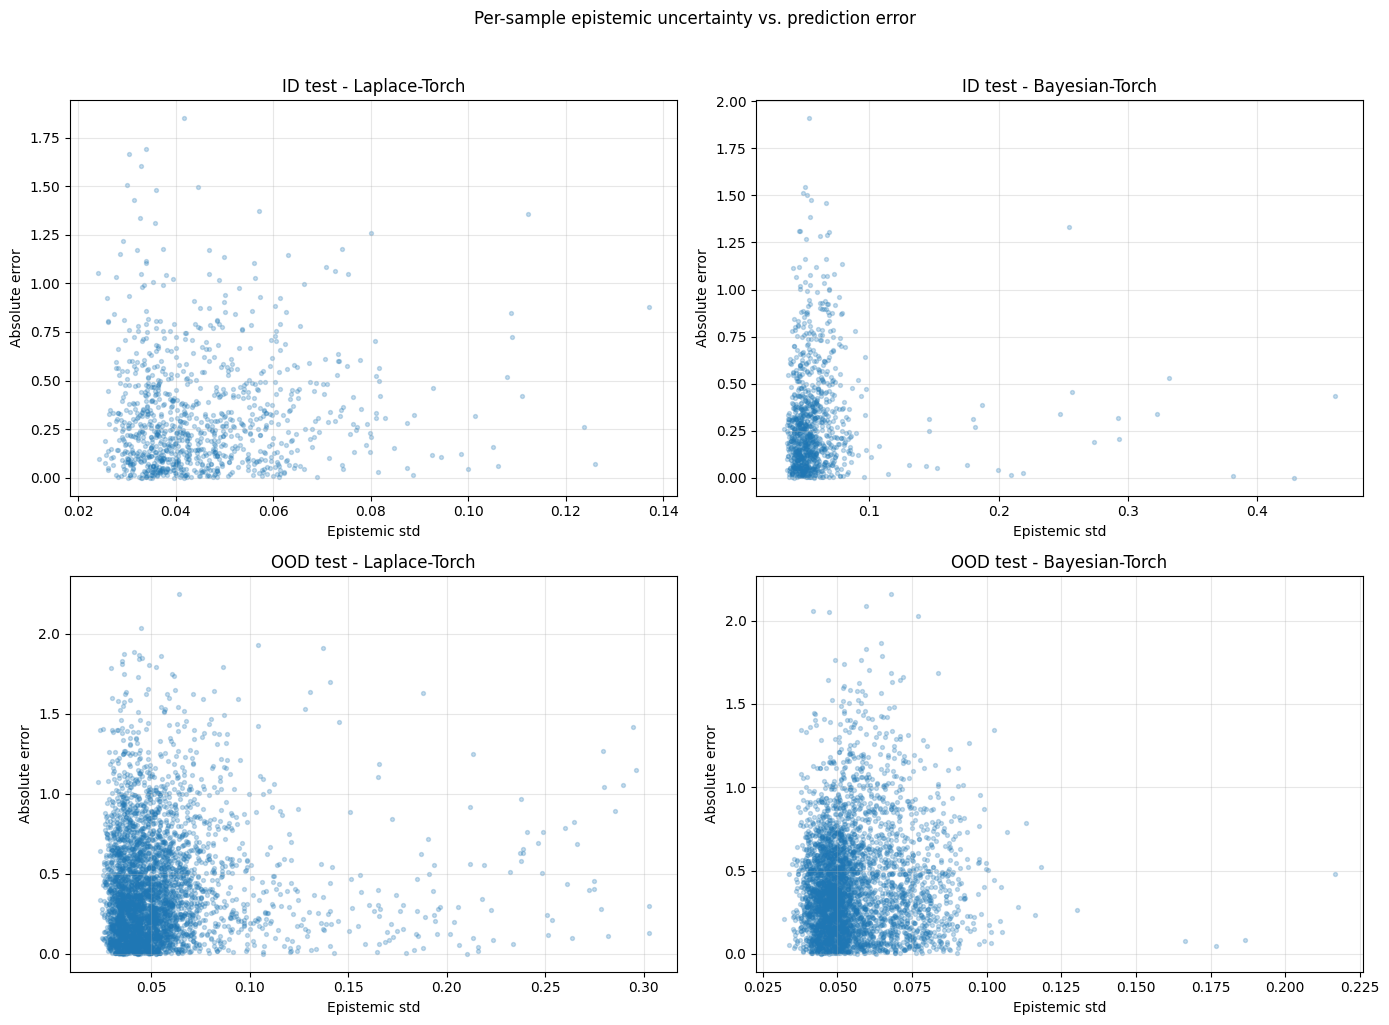

In [ ]:
# Summary/export is handled in the preceding cell.
# This cell is intentionally left as a lightweight placeholder to preserve notebook structure.

## 11. Additional Statistics & Further Analysis
*(This section is intentionally left blank for future inclusion of robust statistical measurements, OOD breakdown analysis, or additional validation plots as requested).*

In [ ]:
print("All tasks complete.")